Задание 1 (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships/data;
2. Провести корреляционный анализ данных о влиянии использования социальных сетей на показатели успеваемости, здоровья и пр.;
3. Проверить значимость полученных коэффициентов корреляции;
4. Сделать выводы.

Первые 5 строк датасета:

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    str    
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score            

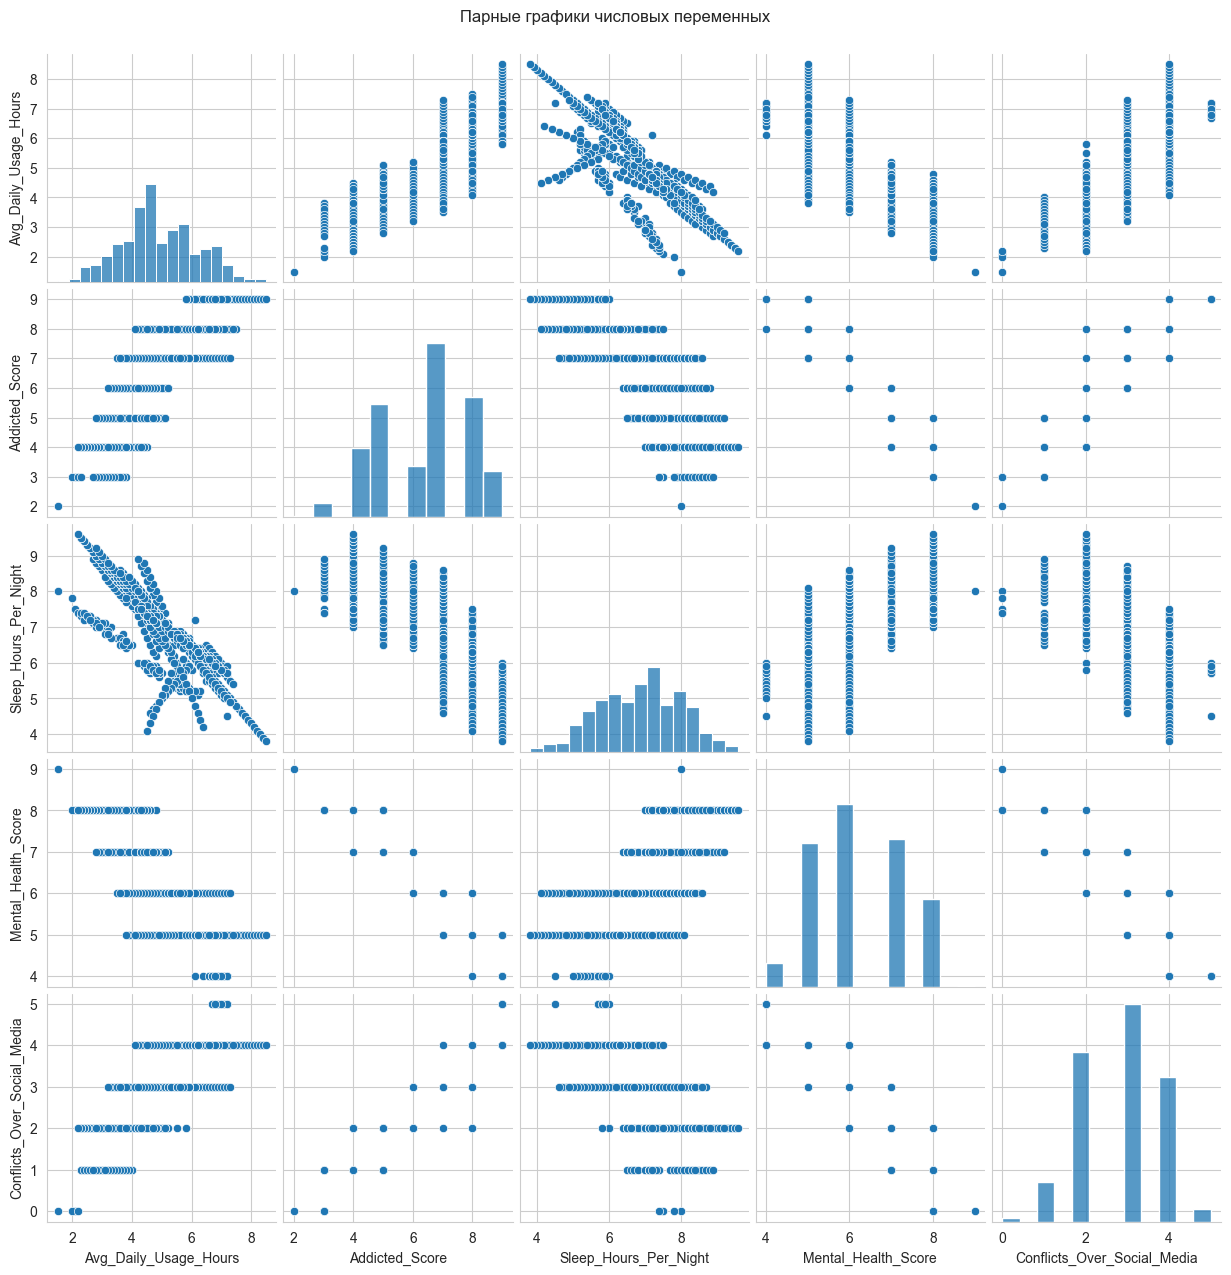

Матрица корреляций Пирсона:
                             Avg_Daily_Usage_Hours  Addicted_Score  \
Avg_Daily_Usage_Hours                     1.000000        0.832000   
Addicted_Score                            0.832000        1.000000   
Sleep_Hours_Per_Night                    -0.790582       -0.764858   
Mental_Health_Score                      -0.801058       -0.945051   
Conflicts_Over_Social_Media               0.804582        0.933586   

                             Sleep_Hours_Per_Night  Mental_Health_Score  \
Avg_Daily_Usage_Hours                    -0.790582            -0.801058   
Addicted_Score                           -0.764858            -0.945051   
Sleep_Hours_Per_Night                     1.000000             0.707439   
Mental_Health_Score                       0.707439             1.000000   
Conflicts_Over_Social_Media              -0.677266            -0.893572   

                             Conflicts_Over_Social_Media  
Avg_Daily_Usage_Hours                    

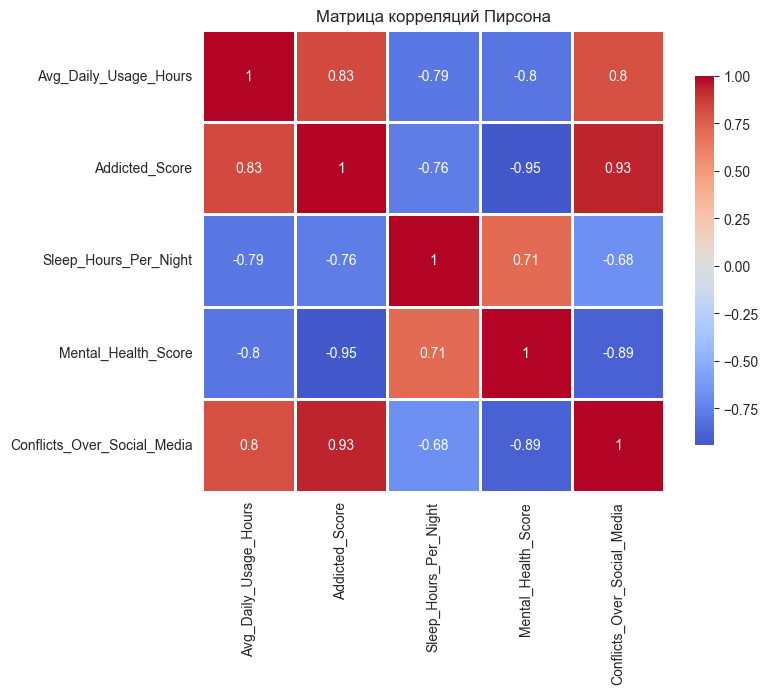

Точечно-бисериальная корреляция между "Зависимость" и "Влияет на учебу": r=0.866, p-value=0.0000
  -> Связь статистически значима.

Корреляция Спирмена между "Зависимость" и "Часы сна": r=-0.788, p-value=0.0000
  -> Связь статистически значима.

Корреляция Спирмена между "Зависимость" и "Ментальное здоровье": r=-0.950, p-value=0.0000
  -> Связь статистически значима.

Корреляция Спирмена между "Часы использования" и "Конфликты": r=0.803, p-value=0.0000
  -> Связь статистически значима.

Таблица сопряженности: Academic_Level vs Affects_Academic_Performance
Affects_Academic_Performance   No  Yes
Academic_Level                        
Graduate                      126  199
High School                     2   25
Undergraduate                 124  229


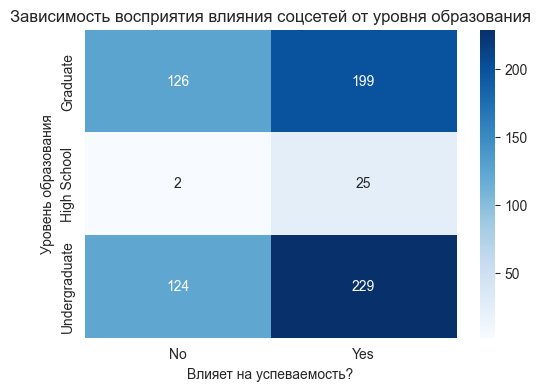

Результаты Хи-квадрат: chi2 = 10.793, p-value = 0.0045, степени свободы = 2
  -> Связь между уровнем образования и восприятием влияния соцсетей статистически значима.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, chi2_contingency, pointbiserialr

sns.set_style("whitegrid")

df = pd.read_csv('Students Social Media Addiction.csv')

print("Первые 5 строк датасета:")
df.head()
print("\nИнформация о датасете:")
df.info()

df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')

numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
                'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].astype('category')

print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())
sns.pairplot(df[['Avg_Daily_Usage_Hours', 'Addicted_Score', 'Sleep_Hours_Per_Night',
                 'Mental_Health_Score', 'Conflicts_Over_Social_Media']])
plt.suptitle('Парные графики числовых переменных', y=1.02)
plt.show()

correlation_matrix_pearson = df[['Avg_Daily_Usage_Hours', 'Addicted_Score',
                                  'Sleep_Hours_Per_Night', 'Mental_Health_Score',
                                  'Conflicts_Over_Social_Media']].corr(method='pearson')
print("Матрица корреляций Пирсона:")
print(correlation_matrix_pearson)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций Пирсона')
plt.show()

df['Affects_Acad_Binary'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})
r_pb, p_value_pb = pointbiserialr(df['Affects_Acad_Binary'], df['Addicted_Score'])
print(f'Точечно-бисериальная корреляция между "Зависимость" и "Влияет на учебу": r={r_pb:.3f}, p-value={p_value_pb:.4f}')
if p_value_pb < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")

r_spearman_sleep, p_value_spearman_sleep = spearmanr(df['Addicted_Score'], df['Sleep_Hours_Per_Night'])
print(f'Корреляция Спирмена между "Зависимость" и "Часы сна": r={r_spearman_sleep:.3f}, p-value={p_value_spearman_sleep:.4f}')
if p_value_spearman_sleep < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")

r_spearman_mental, p_value_spearman_mental = spearmanr(df['Addicted_Score'], df['Mental_Health_Score'])
print(f'Корреляция Спирмена между "Зависимость" и "Ментальное здоровье": r={r_spearman_mental:.3f}, p-value={p_value_spearman_mental:.4f}')
if p_value_spearman_mental < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")

r_spearman_conf, p_value_spearman_conf = spearmanr(df['Avg_Daily_Usage_Hours'], df['Conflicts_Over_Social_Media'])
print(f'Корреляция Спирмена между "Часы использования" и "Конфликты": r={r_spearman_conf:.3f}, p-value={p_value_spearman_conf:.4f}')
if p_value_spearman_conf < 0.05:
    print("  -> Связь статистически значима.\n")
else:
    print("  -> Связь статистически не значима.\n")
    
contingency_table = pd.crosstab(df['Academic_Level'], df['Affects_Academic_Performance'])
print("Таблица сопряженности: Academic_Level vs Affects_Academic_Performance")
print(contingency_table)

plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt='d')
plt.title('Зависимость восприятия влияния соцсетей от уровня образования')
plt.ylabel('Уровень образования')
plt.xlabel('Влияет на успеваемость?')
plt.show()

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Результаты Хи-квадрат: chi2 = {chi2:.3f}, p-value = {p_value:.4f}, степени свободы = {dof}')
if p_value < 0.05:
    print("  -> Связь между уровнем образования и восприятием влияния соцсетей статистически значима.")
else:
    print("  -> Связь статистически не значима.")

Задание* (4 балла)
1. Самостоятельно изучить частные коэффициенты корреляции;
2. Проверить полученные коэффициенты корреляции из задания 1 на влияние других переменных.

In [ ]:
import pingouin as pg

partial_corr = pg.partial_corr(data=df,
                               x='Addicted_Score',
                               y='Conflicts_Over_Social_Media',
                               covar=['Avg_Daily_Usage_Hours'],
                               method='spearman') # Используем метод Спирмена для надежности

print("\n--- Частная корреляция ---")
print("Связь между 'Addicted_Score' и 'Conflicts_Over_Social_Media'")
print("при контроле переменной 'Avg_Daily_Usage_Hours':")
print(partial_corr)


--- Частная корреляция ---
Связь между 'Addicted_Score' и 'Conflicts_Over_Social_Media'
при контроле переменной 'Avg_Daily_Usage_Hours':
            n         r          CI95          p_val
spearman  705  0.855332  [0.83, 0.87]  1.130643e-202
